<a href="https://colab.research.google.com/github/Sanjidarema/CSC477-HW1/blob/main/Breast_Cancer_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Diagnosis Using Machine Learning

Final Project Notebook for CSC 477 / Data Mining.

This project trains and compares several machine learning models for breast cancer classification using the Wisconsin Diagnostic Breast Cancer dataset built into scikit-learn. The target is converted so that **1 = malignant** and **0 = benign**.

## Project Goal

The goal is to build a reproducible machine learning pipeline that classifies breast tumors as benign or malignant, compare models using common evaluation metrics, and identify the best-performing model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)


In [ ]:
# Load the dataset
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y_original = pd.Series(bc.target, name='target')

# scikit-learn uses: 0 = malignant, 1 = benign.
# Convert so the positive class is malignant: 1 = malignant, 0 = benign.
y = (y_original == 0).astype(int)

print('Dataset shape:', X.shape)
print('Class counts:')
print(y.map({0:'Benign', 1:'Malignant'}).value_counts())
X.head()


Dataset shape: (569, 30)
Class counts:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])


Training rows: 455
Testing rows: 114


In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(hidden_layer_sizes=(32,16), max_iter=2000, random_state=42, early_stopping=True))
    ])
}


In [ ]:
rows = []
probas = {}
preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    probas[name] = y_prob
    preds[name] = y_pred

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

results = pd.DataFrame(rows).sort_values('ROC AUC', ascending=False)
results


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
3,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
2,Random Forest,0.973684,1.000000,0.928571,0.962963,0.994378
5,Neural Network,0.894737,0.968750,0.738095,0.837838,0.985450
4,KNN,0.956140,0.974359,0.904762,0.938272,0.982308
1,Decision Tree,0.912281,0.944444,0.809524,0.871795,0.876984


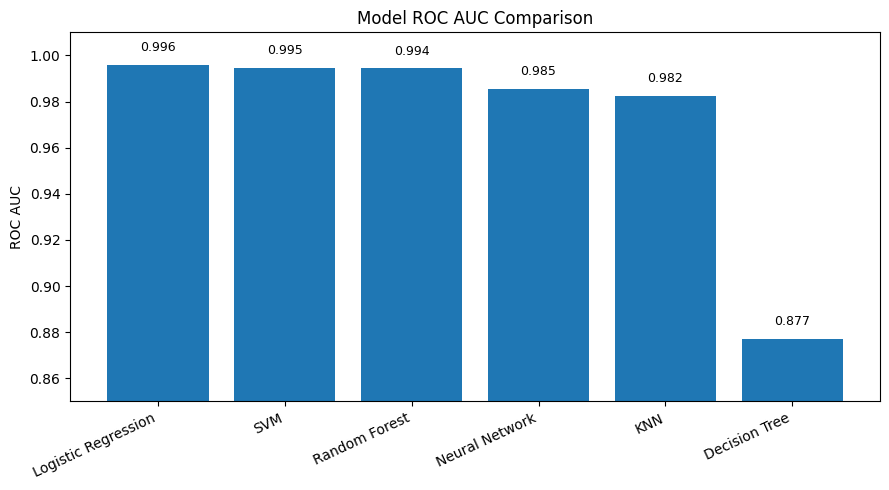

In [ ]:
# Plot ROC AUC comparison
plt.figure(figsize=(9,5))
plt.bar(results['Model'], results['ROC AUC'])
plt.ylim(0.85, 1.01)
plt.title('Model ROC AUC Comparison')
plt.ylabel('ROC AUC')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(results['ROC AUC']):
    plt.text(i, v+0.006, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


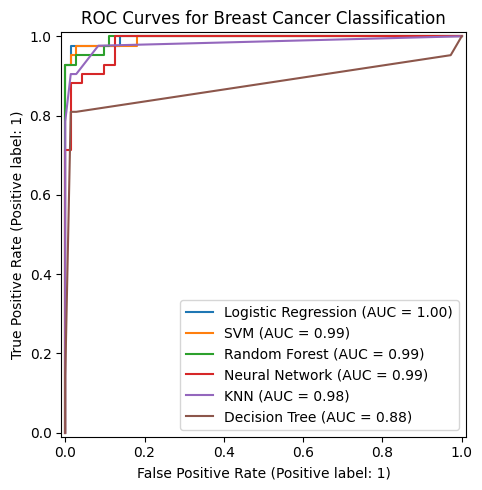

In [ ]:
# Plot ROC curves for every model
plt.figure(figsize=(7,5))
for name in results['Model']:
    RocCurveDisplay.from_predictions(y_test, probas[name], name=name, ax=plt.gca())
plt.title('ROC Curves for Breast Cancer Classification')
plt.tight_layout()
plt.show()


Best model by ROC AUC: Logistic Regression


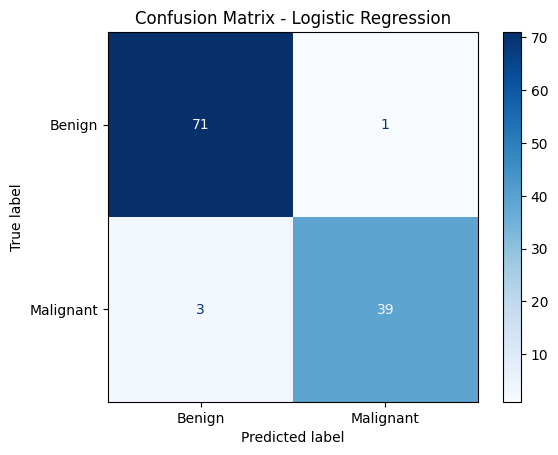

In [ ]:
best_model_name = results.iloc[0]['Model']
best_pred = preds[best_model_name]

print('Best model by ROC AUC:', best_model_name)
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


In [ ]:
# Feature importance using Random Forest
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Conclusion

This project shows that machine learning can classify breast cancer cases using numerical features. Models such as Random Forest, SVM, Logistic Regression, and Neural Networks generally perform strongly on this dataset. The best model should be selected using ROC AUC and also checked with recall because in healthcare a false negative can be serious.